In [2]:
library(tidyverse)
library(reshape2)

source("../theme_ggplot_cfrna.R")
source("../functions.R")
gene_key = read.delim("../gencode.biotype.name.key.tsv")

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ tibble  3.2.1     ✔ dplyr   1.1.4
✔ tidyr   1.3.1     ✔ stringr 1.5.1
✔ readr   2.1.2     ✔ forcats 0.5.1
✔ purrr   1.0.2     

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




In [30]:
read.delim("../1_DATA/sample_meta_passQC.tsv") %>% head

,Record_ID,sample_id,date,timepoint,SCALE_qubit,sample_group,all_comps,transplant_date,date_taper_start,date_taper_end,date_agvhd,date_cgvhd,ORIGIN,timepoint_sym,date_Lgvhd,rel_transplant,rel_agvhd,rel_cgvhd,rel_Lgvhd,HD
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>
1,100,hct_cfrna_301_bp61x61,2019-11-07,3M,1.341502e-09,COMP,_cgvhd_agvhd_bkvd_bkvr,2019-08-08,NA,NA,2019-10-31,2019-10-31,DFCI,3 Month,2019-10-31,91,7,7,7,0
2,100,hct_cfrna_266_bp61x61,2019-09-05,1M,3.738403e-09,COMP,_cgvhd_agvhd_bkvd_bkvr,2019-08-08,NA,NA,2019-10-31,2019-10-31,DFCI,1 Month,2019-10-31,28,-56,-56,-56,0
3,100,hct_cfrna_279_bp61x61,2019-10-03,2M,2.356938e-09,COMP,_cgvhd_agvhd_bkvd_bkvr,2019-08-08,NA,NA,2019-10-31,2019-10-31,DFCI,2 Month,2019-10-31,56,-28,-28,-28,0
4,100,hct_cfrna_280_bp61x61,2020-02-10,6M,7.375081e-09,COMP,_cgvhd_agvhd_bkvd_bkvr,2019-08-08,NA,NA,2019-10-31,2019-10-31,DFCI,6 Month,2019-10-31,186,102,102,102,0
5,100,hct_cfrna_255_bp61x61,2019-08-23,E,3.490448e-10,COMP,_cgvhd_agvhd_bkvd_bkvr,2019-08-08,NA,NA,2019-10-31,2019-10-31,DFCI,Engraftment,2019-10-31,15,-69,-69,-69,0
6,101,gvhd_hct_cfrna_551_bp61x61,2020-03-04,6M,2.975464e-09,COMP,_agvhd,2019-08-20,NA,NA,2020-01-03,NA,DFCI,6 Month,2020-01-03,197,61,NA,61,0


In [71]:
library(ggExtra)
library(ggforce)


# ## load data
mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>%
    filter(ORIGIN == "DFCI") %>%
    mutate(event_sym = factor(timepoint, levels = EVENTS)) %>%
    unique()

metrics = read.delim("../1_DATA/metrics_passQC.tsv")

mdf = mdf %>% mutate(sample_group = factor(sample_group, levels = c("HD", "REF", "COMP"))) 

# Combine with metrics and melt for plotting
mdf_met = merge(mdf, metrics, by="sample_id", all.x=FALSE)

meta = mdf_met


## Log norm
meta$neutrophil_activity = log10(meta$neutrophil_activity)
meta$lymphocyte_activity = log10(meta$lymphocyte_activity)
meta$monocyte_activity = log10(meta$monocyte_activity)




In [72]:
WIDTH= 1.3
HEIGHT= 4

EVENTS_TRN = c("PR","D0","E","1M","2M","3M","6M")


COL_MAN_PAL = c(
                "neutrophil_CBC" = "#3F00FF",
                "lymphocyte_CBC" = "#3F00FF",
                "monocyte_CBC" = "#3F00FF",

                "neutrophil_decon" = "#009E73",
                "lymphocyte_decon" = "#009E73",
                "monocyte_decon" = "#009E73",

                "neutrophil_activity" = "#52BFD8",
                "lymphocyte_activity" = "#52BFD8",
                "monocyte_activity" = "#52BFD8"
                )

# VARS = "neutrophil_activity, lymphocyte_activity, leukocyte_turnover, platelet_turnover, rbc_turnover, monocyte_activity, basophil_turnover, blood_neutrophils, blood_lymphocytes, blood_Leukocytes, blood_Platelets, blood_rbc, blood_monocytes, blood_basophils, decon_neu, decon_lymph, decon_leuk, decon_plat, decon_rbc, decon_mono, decon_baso"
VARS = "neutrophil_activity, lymphocyte_activity, monocyte_activity, neutrophil_CBC, lymphocyte_CBC, monocyte_CBC, neutrophil_decon, lymphocyte_decon, monocyte_decon"
VARS <- strsplit(VARS,", ") %>% unlist()

mdf_plt <- meta %>%
    select(any_of(c("sample_id", "event_sym", VARS))
           ) %>% 
    reshape2::melt(id.vars = c("sample_id", "event_sym")) %>%
    rename(measurement = variable, value = value) %>% 
    mutate(value = ifelse(grepl("turnover",measurement),log10(value),value)) %>% 
    # mutate(value = log10(value)) %>% 
    mutate(event_sym = factor(event_sym, levels = EVENTS_TRN)) %>% 
    mutate(measurement = factor(measurement, levels = names(COL_MAN_PAL))) %>%
    filter(!is.na(event_sym))  


    
mdf_plt %>% head()



,sample_id,event_sym,measurement,value
,<chr>,<fct>,<fct>,<dbl>
1,gvhd_hct_cfrna_1_bp51x51,2M,neutrophil_activity,NA
2,gvhd_hct_cfrna_100_bp61x61,2M,neutrophil_activity,-11.05637
3,gvhd_hct_cfrna_101_bp61x61,2M,neutrophil_activity,-14.58974
4,gvhd_hct_cfrna_102_bp61x61,3M,neutrophil_activity,-14.88386
5,gvhd_hct_cfrna_103_bp61x61,3M,neutrophil_activity,-11.07690
6,gvhd_hct_cfrna_104_bp61x61,PR,neutrophil_activity,-13.83696


In [73]:
meta %>% select(monocyte_activity, lymphocyte_activity, neutrophil_activity) %>% head()

,monocyte_activity,lymphocyte_activity,neutrophil_activity
,<dbl>,<dbl>,<dbl>
1,NA,NA,NA
2,-12.33981,NA,-11.05637
3,-12.17474,-9.564980,-14.58974
4,-13.53427,-9.966486,-14.88386
5,-11.80721,-10.199979,-11.07690
6,NA,-11.420886,-13.83696


In [74]:
### neutrophil plot

CT = "Neutrophil"

neu_plt <- mdf_plt %>% 
    filter(grepl("neu|Neu",measurement)) %>% 
        ggplot(aes(x=event_sym, y=value, color = measurement))+
    # geom_boxplot(outlier.shape=NA)+
    geom_violin(scale ="width")+
    geom_jitter(width = 0.2, height = 0, alpha = 0.75, size = .75, stroke=NA)+
    # geom_point(position =  position_jitterdodge(jitter.height=0, 
    #                                         jitter.width=.25, 
    #                                         seed=42))+
    theme_cfrna_print()+
    labs(title=CT)+
    theme(
        plot.title = element_text(size = 8, hjust = 0.5, vjust = -2.5),
        axis.title.x = element_blank(),
        axis.title.y =element_blank(),
        legend.position = "none",
        strip.background = element_blank(),
  strip.text.x = element_blank())+
    scale_color_manual(values = COL_MAN_PAL)+
    facet_wrap(~measurement, scales="free_y", ncol = 1)+
    scale_x_discrete(guide = guide_axis(n.dodge = 2))
    
#   pdf(file=paste0("figures/TURNOVER_",CT,"-BOX.pdf"),
#           width=WIDTH,height=HEIGHT, paper="special", bg="white",
#           fonts="Helvetica", colormodel = "srgb", pointsize=6, useDingbats = FALSE)
#   print(ct_plt)
#   dev.off()

In [75]:
CT = "Lymphocyte"

lym_plt <- mdf_plt %>% 
    filter(grepl("lymph|Lym",measurement)) %>% 
    ggplot(aes(x=event_sym, y=value, color = measurement))+
    # geom_boxplot(outlier.shape=NA)+
    geom_violin(scale ="width")+
    geom_jitter(width = 0.2, height = 0, alpha = 0.75, size = .75, stroke=NA)+
    # geom_point(position =  position_jitterdodge(jitter.height=0, 
    #                                         jitter.width=.25, 
    #                                         seed=42))+
    theme_cfrna_print()+
    labs(title=CT)+
    theme(
        plot.title = element_text(size = 8, hjust = 0.5, vjust = -2.5),
        axis.title.x = element_blank(),
        axis.title.y =element_blank(),
        legend.position = "none",
        strip.background = element_blank(),
  strip.text.x = element_blank())+
    scale_color_manual(values = COL_MAN_PAL)+
    facet_wrap(~measurement, scales="free_y", ncol = 1)+
    scale_x_discrete(guide = guide_axis(n.dodge = 2))
    
  # pdf(file=paste0("figures/TURNOVER_",CT,"-BOX.pdf"),
  #         width=WIDTH,height=HEIGHT, paper="special", bg="white",
  #         fonts="Helvetica", colormodel = "srgb", pointsize=6, useDingbats = FALSE)
  # print(ct_plt)
  # dev.off()

In [76]:
### neutrophil plot

CT = "Monocyte"

mono_plt <- mdf_plt %>% 
    filter(grepl("mono|Mono",measurement)) %>% 
        ggplot(aes(x=event_sym, y=value, color = measurement))+
    # geom_boxplot(outlier.shape=NA)+
    geom_violin(scale ="width")+
    geom_jitter(width = 0.2, height = 0, alpha = 0.75, size = .75, stroke=NA)+
    # geom_point(position =  position_jitterdodge(jitter.height=0, 
    #                                         jitter.width=.25, 
    #                                         seed=42))+
    theme_cfrna_print()+
    labs(title=CT)+
    theme(
        plot.title = element_text(size = 8, hjust = 0.5, vjust = -2.5),
        axis.title.x = element_blank(),
        axis.title.y =element_blank(),
        legend.position = "none",
        strip.background = element_blank(),
  strip.text.x = element_blank())+
    scale_color_manual(values = COL_MAN_PAL)+
    facet_wrap(~measurement, scales="free_y", ncol = 1)+
    scale_x_discrete(guide = guide_axis(n.dodge = 2))
    
# WIDTH_CUSTOM = 1.38
#   pdf(file=paste0("figures/TURNOVER_",CT,"-BOX.pdf"),
#           width=WIDTH_CUSTOM,height=HEIGHT, paper="special", bg="white",
#           fonts="Helvetica", colormodel = "srgb", pointsize=6, useDingbats = FALSE)
#   print(ct_plt)
#   dev.off()

In [77]:
library(patchwork)

Warning message:
“Removed 67 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


Warning message:
“Removed 67 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 88 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 88 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 87 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 87 rows containing missing values or values outside the scale range
(`geom_point()`).”


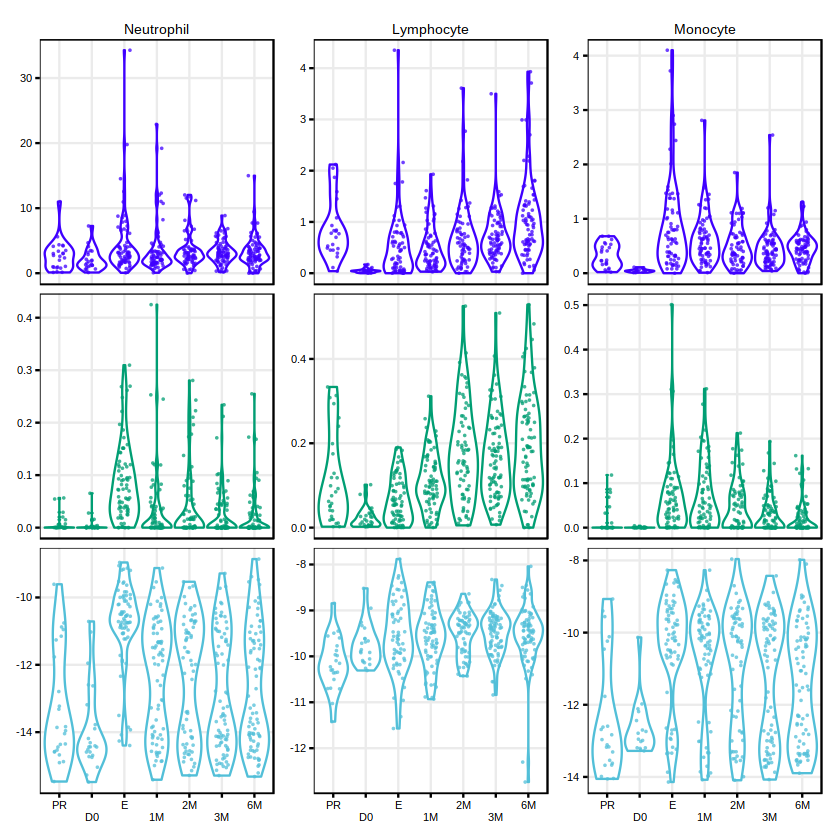

In [78]:
neu_plt + lym_plt + mono_plt